# 📚 *Medical Image Processing*
## 🧠 **Liver Segmentation Challenge**
### 🖥️ Training Script

---

### 👩‍🔬 **Authors**
- **Danna Barrientos — s335116**
- **Sofía Escobar — s336895**
- **Felipe Medina — s335131**
- **Matteo Canal — s345814**

---



1. Connection with Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # Mounts Google Drive to the Colab environment at /content/drive

Mounted at /content/drive


2. Imports

In [ ]:
# ===== Core & Utils =====
import os, json, shutil, random  # os for path operations, json for config files, shutil for file operations, random for data splitting.
import numpy as np             # Numerical operations, especially for array manipulation.
from tqdm import tqdm          # Progress bars for loops.
import re                      # Regular expressions for string manipulation (e.g., extracting IDs from filenames).

def _stem(fname):
    """Extracts the filename without its extension."""
    return os.path.splitext(fname)[0]

def _extract_id(s):
    """
    Extracts a numeric ID from a filename stem.
    Defaults to the stem if no numeric ID is found.
    """
    st = _stem(s)
    nums = re.findall(r"\d+", st)
    return nums[-1] if len(nums) > 0 else st

# If you already import these elsewhere, keep them. Needed only if USE_POSTPROC=True.
from skimage import measure, morphology, segmentation
from scipy import ndimage as ndi

# ===== Image Processing =====
import cv2                     # OpenCV for image manipulation, especially connected components.
from PIL import Image          # Python Imaging Library for image loading and resizing.
from skimage import morphology, measure, segmentation # Scikit-image for morphological operations, label analysis, and segmentation.
from scipy import ndimage as ndi # SciPy for n-dimensional image processing, e.g., distance transforms.

# ===== Visualization =====
import matplotlib.pyplot as plt # Matplotlib for plotting and visualization of training history and predictions.

# ===== ML / Deep Learning =====
import torch                   # PyTorch deep learning framework.
import torch.nn as nn          # Neural network modules.
import random
import torch.nn.functional as F # Functional interface for common neural network operations.
import torch.optim as optim    # Optimization algorithms (e.g., Adam).
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler # Utilities for data handling.
from torchvision import transforms     # Image transformations for data augmentation and preprocessing.
from torchvision.transforms import InterpolationMode # Enum for interpolation methods in transforms.
import torchvision             # Torchvision for datasets, models, and image transformations.

# ===== Dataset Split =====
from sklearn.model_selection import train_test_split # Utility for splitting datasets into train/validation/test sets.

3. Paths

In [ ]:
# ===== Dataset Paths =====
RUN_ID = "ABL-33" # Unique identifier for the current experimental run.
PROJECT_ROOT = "/content/drive/MyDrive/Challenge_Liver_MIP" # Base directory for the entire project in Google Drive.

# Dataset variants (switch only this variable for ablation)
# DATASET_NAME = "DATASET_liver_stu"          # baseline (BL-0) - Original dataset. (ABL-8) - (ABL-32)
# DATASET_NAME = "DATASET_liver_stu_LAB"    # LAB-safe preprocessing (ABL-1) - Dataset with LAB color space preprocessing.
# DATASET_NAME = "DATASET_liver_stu_LAB_ABL_2"    # LAB-safe preprocessing (ABL-2) - Another variant of LAB preprocessing.
# DATASET_NAME = "DATASET_liver_stu_CLAHE_L"  # (ABL-3) CLAHE preprocessing - Dataset with CLAHE enhancement.
# DATASET_NAME = "DATASET_liver_stu_REINHARD" #  (ABL-4) Reinhard
# DATASET_NAME = "DATASET_liver_stu_MACENKO_SOFT" #  (ABL-5) Macenko
DATASET_NAME = "DATASET_liver_stu_MACENKO_SOFT_ABL_6" #  (ABL-6) (ABL-33) Macenko
# DATASET_NAME = "DATASET_liver_stu_MACENKO_MT_SOFT_ABL_7" #  (ABL-7) Macenko


# DATASET_NAME = "DATASET_liver_stu_STAIN"  # stain augmentation (offline) - Dataset with stain normalization/augmentation.

DATASET_ROOT = os.path.join(PROJECT_ROOT, DATASET_NAME) # Full path to the active dataset variant.

4. Enviroment and model

In [ ]:
# ===== Environment Check (Versions + CUDA) =====
print(f"torch={torch.__version__} | torchvision={torchvision.__version__} | cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ===== Model: U-Net (Configurable) =====
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]

        if dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))

        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    """
    U-Net architecture for semantic segmentation, configurable by depth and initial filter count.
    It consists of an encoder (downsampling path) and a decoder (upsampling path) with skip connections.

    Attributes:
        in_channels (int): Number of input channels (e.g., 3 for RGB images).
        out_channels (int): Number of output channels (e.g., 1 for binary masks).
        init_filters (int): Number of filters in the first convolutional block.
        depth (int): Number of downsampling/upsampling stages.
        bilinear (bool): If True, uses bilinear upsampling; otherwise, uses ConvTranspose2d.
    """
    def __init__(self,
                 in_channels: int = 3,
                 out_channels: int = 1,
                 init_filters: int = 32,
                 depth: int = 4,
                 bilinear: bool = True):
        super().__init__()
        self.depth = depth
        self.pool = nn.MaxPool2d(2) # Max pooling for downsampling in the encoder.

        # Encoder (Downsampling Path)
        self.down = nn.ModuleList()
        ch = in_channels
        f = init_filters
        for _ in range(depth):
            self.down.append(DoubleConv(ch, f)) # Add a DoubleConv block.
            ch = f
            f *= 2 # Double the filter count for the next stage.

        # Bottleneck (Innermost layer between encoder and decoder)
        self.bottleneck = DoubleConv(ch,f,dropout_p=0)


        # Decoder (Upsampling Path)
        self.up = nn.ModuleList()
        for _ in range(depth):
            f //= 2 # Halve the filter count for the current upsampling stage.
            if bilinear:
                up = nn.Sequential(
                    nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False), # Bilinear upsampling.
                    nn.Conv2d(f * 2, f, kernel_size=1, bias=False), # Convolution to reduce channels after upsampling.
                )
            else:
                up = nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2) # Transposed convolution for upsampling.

            self.up.append(nn.ModuleDict({
                "up": up,                            # Upsampling layer.
                "conv": DoubleConv(f * 2, f),        # DoubleConv block after concatenating with skip connection.
            }))

        # Output head (Final convolution to produce the desired number of output channels).
        self.out_conv = nn.Conv2d(init_filters, out_channels, kernel_size=1)

    def forward(self, x):
        skips = [] # List to store feature maps for skip connections.

        # Encoder Pass
        for enc in self.down:
            x = enc(x) # Apply DoubleConv.
            skips.append(x) # Store for skip connection.
            x = self.pool(x) # Downsample.

        # Bottleneck Pass
        x = self.bottleneck(x)

        # Decoder Pass
        for i in range(self.depth):
            skip = skips[-(i + 1)] # Retrieve corresponding skip connection from the encoder.
            x = self.up[i]["up"](x) # Upsample.

            # Safety check for size mismatch due to odd input dimensions (rare).
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1) # Concatenate skip connection with upsampled features.
            x = self.up[i]["conv"](x)      # Apply DoubleConv.

        return self.out_conv(x) # Final output.

torch=2.9.0+cu128 | torchvision=0.24.0+cu128 | cuda=True
GPU: Tesla T4


5. Loss functions

In [ ]:
# ============================================
# Loss Functions (Binary Segmentation)
# ============================================

class DiceLoss(nn.Module):
    """
    Soft Dice loss for binary segmentation.
    Expects logits as inputs (applies sigmoid internally to convert to probabilities).
    """
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth # Smoothing factor to prevent division by zero.

    def forward(self, inputs, targets):
        probs = torch.sigmoid(inputs) # Convert logits to probabilities.

        probs = probs.view(-1)      # Flatten prediction tensor.
        targets = targets.view(-1)  # Flatten target tensor.

        intersection = (probs * targets).sum() # Calculate intersection.
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth) # Dice formula.
        return 1.0 - dice # Return 1 - Dice for minimization (loss function).


class BCEDiceLoss(nn.Module):
    """
    Weighted sum of BCEWithLogitsLoss and DiceLoss.
    This combination often provides a good balance for segmentation tasks, handling both pixel-wise classification and overlap.
    """
    def __init__(self, w_bce: float = 0.5, w_dice: float = 0.5, smooth: float = 1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss() # Binary Cross-Entropy with Logits loss.
        self.dice = DiceLoss(smooth=smooth) # Dice Loss.
        self.w_bce = w_bce # Weight for BCE loss.
        self.w_dice = w_dice # Weight for Dice loss.

    def forward(self, inputs, targets):
        targets = targets.float() # Ensure targets are float type.
        loss_bce = self.bce(inputs, targets) # Compute BCE loss.
        loss_dice = self.dice(inputs, targets) # Compute Dice loss.
        return self.w_bce * loss_bce + self.w_dice * loss_dice # Weighted sum of losses.


class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky loss for imbalanced binary segmentation.
    Combines Tversky Index with a Focal-like weighting to focus on hard-to-classify examples.
    Expects logits by default (applies sigmoid internally to convert to probabilities).
    """
    def __init__(self,
                 alpha: float = 0.7,
                 beta: float = 0.3,
                 gamma: float = 0.75,
                 smooth: float = 1e-6,
                 from_logits: bool = True):
        super().__init__()
        self.alpha = alpha # Weight for false negatives (controls sensitivity).
        self.beta = beta   # Weight for false positives (controls specificity).
        self.gamma = gamma # Focusing parameter (similar to Focal Loss).
        self.smooth = smooth # Smoothing factor.
        self.from_logits = from_logits # Flag to indicate if inputs are logits.

    def forward(self, inputs, targets):
        targets = targets.float() # Ensure targets are float type.
        probs = torch.sigmoid(inputs) if self.from_logits else inputs # Convert logits to probabilities if necessary.

        probs = probs.contiguous().view(probs.size(0), -1)      # Flatten predictions.
        targets = targets.contiguous().view(targets.size(0), -1) # Flatten targets.

        tp = (probs * targets).sum(dim=1)             # True Positives.
        fp = (probs * (1.0 - targets)).sum(dim=1)     # False Positives.
        fn = ((1.0 - probs) * targets).sum(dim=1)     # False Negatives.

        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth) # Tversky Index formula.
        return torch.pow((1.0 - tversky), self.gamma).mean() # Return Focal Tversky Loss.


class BCEFocalTverskyLoss(nn.Module):
    """
    Weighted sum of BCEWithLogitsLoss and FocalTverskyLoss.
    Offers a robust loss for challenging segmentation tasks, especially with class imbalance.
    """
    def __init__(self,
                 w_bce: float = 0.3,
                 w_ft: float = 0.7,
                 alpha: float = 0.75,
                 beta: float = 0.25,
                 gamma: float = 0.75):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss() # Binary Cross-Entropy with Logits loss.
        self.ft = FocalTverskyLoss(alpha=alpha, beta=beta, gamma=gamma, from_logits=True) # Focal Tversky Loss.
        self.w_bce = w_bce # Weight for BCE loss.
        self.w_ft = w_ft   # Weight for Focal Tversky loss.

    def forward(self, inputs, targets):
        targets = targets.float() # Ensure targets are float type.
        return self.w_bce * self.bce(inputs, targets) + self.w_ft * self.ft(inputs, targets) # Weighted sum of losses.

6. Define hyperparameters for network training

In [ ]:
# ============================================
# Baseline Configuration (Minimal + Reproducible)
# ============================================

# --- Model / Input ---
INPUT_SIZE   = (416, 416) # Input image dimensions (height, width).
IN_CHANNELS  = 3          # Number of input channels (e.g., 3 for RGB).
OUT_CHANNELS = 1          # Number of output channels (e.g., 1 for binary segmentation mask).
INIT_FILTERS = 32         # Initial number of convolutional filters in the U-Net's first block.
DEPTH        = 4          # Number of downsampling/upsampling stages in the U-Net.
BILINEAR_UP  = True       # Use bilinear upsampling in the decoder if True; otherwise, use ConvTranspose2d.

# --- Training ---
CRITERION_NAME = "bce_dice"   # Specifies the loss function to use. Options: "dice", "bce_dice", "focal_tversky", "bce_focal_tversky".
N_EPOCHS       = 150           # Total number of training epochs.
BATCH_SIZE     = 4            # Number of samples per training batch.
LR             = 1e-4         # Learning rate for the optimizer.
CHECKPOINT_FREQ = 1           # Frequency (in epochs) at which model checkpoints are saved.

# --- Validation ---
VAL_THRESH     = 0.5         # Threshold for converting probability maps to binary masks during validation.

# --- Paths (derived from DATASET_ROOT defined earlier) ---
TRAIN_IMG_DIR  = os.path.join(DATASET_ROOT, "train", "image")     # Directory containing training images.
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT, "train", "manual_py") # Directory containing training masks.
VAL_IMG_DIR    = os.path.join(DATASET_ROOT, "val", "image")       # Directory containing validation images.
VAL_MASK_DIR   = os.path.join(DATASET_ROOT, "val", "manual_py")   # Directory containing validation masks.

CHECKPOINT_DIR = os.path.join(DATASET_ROOT, "checkpoints", RUN_ID) # Directory to save model checkpoints and run logs.
os.makedirs(CHECKPOINT_DIR, exist_ok=True) # Create the checkpoint directory if it does not exist.

# --- Loss factory (keeps the baseline simple and switchable) ---
def build_criterion(name: str):
    """Factory function to instantiate the chosen loss function based on its name."""
    name = name.lower()
    if name == "dice":
        return DiceLoss()
    if name == "bce_dice":
        return BCEDiceLoss(w_bce=0.5, w_dice=0.5)
    if name == "focal_tversky":
        return FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)
    if name == "bce_focal_tversky":
        return BCEFocalTverskyLoss(w_bce=0.3, w_ft=0.7, alpha=0.75, beta=0.25, gamma=0.75)
    raise ValueError(f"Unknown CRITERION_NAME: {name}")

criterion = build_criterion(CRITERION_NAME) # Instantiate the loss function.

# --- Save run config (baseline-friendly) ---
run_config = {
    "dataset_root": DATASET_ROOT,
    "input_size": INPUT_SIZE,
    "in_channels": IN_CHANNELS,
    "out_channels": OUT_CHANNELS,
    "init_filters": INIT_FILTERS,
    "depth": DEPTH,
    "bilinear_up": BILINEAR_UP,
    "criterion": CRITERION_NAME,
    "n_epochs": N_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "checkpoint_freq": CHECKPOINT_FREQ,
    "val_thresh": VAL_THRESH,
    "min_obj_area": MIN_OBJ_AREA,
}

config_path = os.path.join(CHECKPOINT_DIR, "run_config.json") # Path to save the run configuration.
with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2) # Save configuration to a JSON file.

print(f"Config saved: {config_path}")
print(f"Train images: {TRAIN_IMG_DIR}")
print(f"Val images:   {VAL_IMG_DIR}")

Config saved: /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/run_config.json
Train images: /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/train/image
Val images:   /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/val/image


7. Dataloader definition

In [ ]:
# ============================================================
# DATA PIPELINE (COMPLETE) — Dataset + Transforms + Sampler + Loaders
# IMPORTANT:
# - This block DEFINES USE_SAMPLER (so it cannot be "missing").
# - It uses your Baseline Configuration names:
#   INPUT_SIZE, BATCH_SIZE, TRAIN_IMG_DIR, TRAIN_MASK_DIR, VAL_IMG_DIR, VAL_MASK_DIR
# ============================================================

# ------------------------------------------------------------
# 0) Flags (Ablation Control) — DATA LOADER LEVEL
# ------------------------------------------------------------
USE_SAMPLER = False   # True -> WeightedRandomSampler, False -> shuffle=True baseline
USE_AUGMENTATION = False  # True -> apply JointAugment to TRAIN only

# ------------------------------------------------------------
# 1) Matched Dataset (robust image-mask pairing + correct binary masks)
# ------------------------------------------------------------

def _stem(fname):
    """Return filename without extension."""
    return os.path.splitext(fname)[0]

def _extract_id(s):
    """
    Extract a numeric ID from a filename stem.
    Fallback: return stem if no digits are found.
    """
    st = _stem(s)
    nums = re.findall(r"\d+", st)
    return nums[-1] if len(nums) > 0 else st

# Data Agumetnation
class JointAugment:
    """
    Augmentations for segmentation:
    - Geometric: it's the same for image and mask
    - Color: Just image
    """
    def __init__(self, p_flip=0.5, max_rotate=30, p_color=0.8):
        self.p_flip = p_flip
        self.max_rotate = max_rotate
        self.p_color = p_color

    def __call__(self, img_pil, mask_pil):
        # --- Flips (boths) ---
        if random.random() < self.p_flip:
            img_pil = TF.hflip(img_pil)
            mask_pil = TF.hflip(mask_pil)

        if random.random() < self.p_flip:
            img_pil = TF.vflip(img_pil)
            mask_pil = TF.vflip(mask_pil)

        # --- Rotation (both)) ---
        angle = random.uniform(-self.max_rotate, self.max_rotate)
        img_pil  = TF.rotate(img_pil,  angle, interpolation=InterpolationMode.BILINEAR)
        mask_pil = TF.rotate(mask_pil, angle, interpolation=InterpolationMode.NEAREST)

        # --- Color (just image) ---
        if random.random() < self.p_color:
            img_pil = TF.adjust_brightness(img_pil, 1.0 + random.uniform(-0.15, 0.15))
            img_pil = TF.adjust_contrast(img_pil,   1.0 + random.uniform(-0.15, 0.15))
            img_pil = TF.adjust_saturation(img_pil, 1.0 + random.uniform(-0.10, 0.10))

        return img_pil, mask_pil


class LiverDatasetMatched(Dataset):
    """
    Custom PyTorch Dataset for loading liver images and their corresponding segmentation masks.
    It robustly matches image files to mask files based on their names or extracted numeric IDs.
    Handles mask binarization and ensures consistent sizing.

    Attributes:
        image_dir (str): Path to the directory containing image files.
        mask_dir (str): Path to the directory containing mask files.
        input_size (tuple): Target size (height, width) for resizing images and masks.
        img_transform (torchvision.transforms.Compose): Transformations to apply to images.
    """

    def __init__(self, image_dir, mask_dir, input_size=(416, 416), img_transform=None, joint_aug=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.input_size = input_size
        self.img_transform = img_transform
        self.joint_aug = joint_aug

        self.images = sorted([f for f in os.listdir(image_dir) if not f.startswith(".")]) # List of image filenames.
        self.masks  = sorted([f for f in os.listdir(mask_dir)  if not f.startswith(".")])  # List of mask filenames.

        self.mask_by_stem = {_stem(f): f for f in self.masks} # Map mask stem to full filename for quick lookup.
        self.mask_by_id   = {_extract_id(f): f for f in self.masks} # Map extracted ID to full filename.

        self.pairs = []    # List to store matched (image_filename, mask_filename) pairs.
        missing = []      # List to store images without a matching mask.

        for img_f in self.images:
            img_stem = _stem(img_f)

            if img_stem in self.mask_by_stem: # Attempt exact stem match.
                self.pairs.append((img_f, self.mask_by_stem[img_stem]))
                continue

            img_id = _extract_id(img_f) # Attempt match by extracted numeric ID.
            if img_id in self.mask_by_id:
                self.pairs.append((img_f, self.mask_by_id[img_id]))
                continue

            missing.append(img_f) # If no match found, add to missing list.

        print(f"[Dataset] images: {len(self.images)} | masks: {len(self.masks)} | matched pairs: {len(self.pairs)}")
        if len(missing) > 0:
            print(f"[Dataset] WARNING: {len(missing)} images without a matching mask (first 5): {missing[:5]}")

        assert len(self.pairs) > 0, "No image-mask pairs found. Check your folders/naming." # Ensure at least one pair is found.

    def __len__(self):
        return len(self.pairs) # Returns the total number of matched image-mask pairs.

    def __getitem__(self, idx):
        img_name, msk_name = self.pairs[idx]
        img_path = os.path.join(self.image_dir, img_name)
        msk_path = os.path.join(self.mask_dir,  msk_name)

        # -------------------------
        # Image (RGB)
        # -------------------------
        image = Image.open(img_path).convert("RGB") # Load image and convert to RGB.

        # -------------------------
        # Mask (binary)
        # -------------------------
        mask_pil = Image.open(msk_path).convert("L") # Load mask as grayscale.

        # Apply joint augmentation on PIL (TRAIN only if provided)
        if self.joint_aug is not None:
            image, mask_pil = self.joint_aug(image, mask_pil)

        # transform image / resize mask
        if self.img_transform is not None:
            image = self.img_transform(image) # Apply image transformations.
        else:
            image = transforms.Resize(self.input_size, interpolation=InterpolationMode.BILINEAR)(image) # Resize if no custom transform.
            image = transforms.ToTensor()(image) # Convert to PyTorch tensor.

        mask_pil = mask_pil.resize(self.input_size, resample=Image.NEAREST) # Resize mask using NEAREST interpolation to preserve labels.

        mask_np = np.array(mask_pil, dtype=np.uint8) # Convert PIL image to NumPy array.
        mask_np = (mask_np > 0).astype(np.uint8)   # Binarize mask: robust for 0/1 and 0/255 values.

        mask = torch.from_numpy(mask_np).float().unsqueeze(0)  # Convert to PyTorch tensor (1,H,W) and float type.

        return image, mask # Return processed image and mask tensors.


# ------------------------------------------------------------
# 2) Image Transform (Baseline)
# ------------------------------------------------------------

img_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE, interpolation=InterpolationMode.BILINEAR), # Resize images to a consistent input size.
    transforms.ToTensor(),                                                 # Convert PIL Image to PyTorch Tensor.
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])         # Normalize image pixel values to [-1, 1].
])


# ------------------------------------------------------------
# 2.5) Joint Augment (TRAIN only)
# ------------------------------------------------------------

# Create augmentation object only if enabled
train_joint_aug = JointAugment(
    p_flip=0.5,
    max_rotate=30,
    p_color=0.8
) if USE_AUGMENTATION else None


# ------------------------------------------------------------
# 3) Datasets (MUST be defined before DataLoaders)
# ------------------------------------------------------------

train_dataset = LiverDatasetMatched(
    image_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    input_size=INPUT_SIZE,
    img_transform=img_transform,
    joint_aug=train_joint_aug     # >>> ADDED: augmentation only for TRAIN <<<
) # Instantiate training dataset.

val_dataset = LiverDatasetMatched(
    image_dir=VAL_IMG_DIR,
    mask_dir=VAL_MASK_DIR,
    input_size=INPUT_SIZE,
    img_transform=img_transform,
    joint_aug=None                # NO augmentation for VAL
) # Instantiate validation dataset.

print(f"[INFO] Train dataset size: {len(train_dataset)}")
print(f"[INFO] Val dataset size:   {len(val_dataset)}")

# ------------------------------------------------------------
# 4) Optional: Weighted Sampler (Ablation)
# ------------------------------------------------------------

def build_weighted_sampler_from_dataset(dataset):
    """
    Builds a WeightedRandomSampler aligned with dataset order (dataset.pairs).
    Oversamples samples whose masks have higher foreground fraction.
    """
    pos_fracs = []
    for (_, msk_name) in dataset.pairs:
        msk_path = os.path.join(dataset.mask_dir, msk_name)
        m = np.array(Image.open(msk_path).convert("L"))
        pos_fracs.append((m > 0).mean())

    pos_fracs = np.asarray(pos_fracs, dtype=np.float32)
    p90 = np.percentile(pos_fracs, 90) + 1e-8

    weights = 0.2 + 0.8 * np.clip(pos_fracs / p90, 0, 1)
    weights = weights.astype(np.float32)

    return WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )

# ------------------------------------------------------------
# 5) DataLoaders (Baseline vs Sampler Ablation)
# ------------------------------------------------------------

if USE_SAMPLER:
    sampler = build_weighted_sampler_from_dataset(train_dataset) # Build weighted sampler if enabled.
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    ) # DataLoader using WeightedRandomSampler.
    print("[INFO] Train loader: WeightedRandomSampler enabled.")
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    ) # Standard DataLoader with shuffling.
    print("[INFO] Train loader: Standard shuffle enabled (baseline).")

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
) # Validation DataLoader (no shuffling for consistent evaluation).

print("[INFO] Val loader: shuffle=False (fixed).")
print("[INFO] Data pipeline created successfully.")


[Dataset] images: 403 | masks: 403 | matched pairs: 403
[Dataset] images: 56 | masks: 56 | matched pairs: 56
[INFO] Train dataset size: 403
[INFO] Val dataset size:   56
[INFO] Train loader: Standard shuffle enabled (baseline).
[INFO] Val loader: shuffle=False (fixed).
[INFO] Data pipeline created successfully.


8. Pre-training

In [ ]:
# ============================================
# BLOCK 1/2 — GLOBAL FLAGS + DEVICE/MODEL/OPTIMIZER + METRICS + POSTPROC + HISTORY + EARLY STOP
# (baseline-consistent, and baseline postprocess is FAST: no skimage.label when USE_POSTPROC=False)
# ============================================
# ----------------------------------------------------------
# GLOBAL FLAGS — BASELINE (Single Source of Truth)
# NOTE: Define flags ONCE here, and only CONSUME them elsewhere.
# ----------------------------------------------------------

# --- Training behavior control ---
USE_EARLY_STOP        = True      # Enable/disable early stopping based on validation metrics.
USE_LR_SCHEDULER      = False      # Enable/disable learning rate scheduler (e.g., ReduceLROnPlateau).

# --- Sampling ablation control ---
USE_SAMPLER           = False      # Enable/disable WeightedRandomSampler for training data.

# --- Post-processing control for validation (applies only during evaluation) ---
USE_POSTPROC          = True      # Enable/disable post-processing (small object removal, hole filling).
USE_WATERSHED         = False      # Enable/disable watershed segmentation (only if USE_POSTPROC=True).

POSTPROC_MODE = "min_area_fill"

# options:
# "none"
# "min_area"
# "min_area_fill"
# "watershed"
# "region_growing"

RG_SEED_THR = 0.80
RG_GROW_THR = 0.50
MIN_OBJ_AREA = 10

# --- Checkpointing and logging behavior ---
SAVE_CHECKPOINTS      = True       # Save model checkpoints periodically.
SAVE_BEST_MODEL       = True       # Save the best performing model based on validation metrics.
CRASH_SAFE_LOGGING    = True       # Save training logs incrementally after each epoch.

# --- Threshold handling for validation/testing ---
USE_THRESHOLD_SWEEP   = False      # Perform a threshold sweep on validation set to find optimal threshold.
USE_SAVED_THRESHOLD   = False      # Use a previously saved optimal threshold (from a sweep).

# --- Early stopping parameters (active if USE_EARLY_STOP is True) ---
EARLYSTOP_PATIENCE    = 8          # Number of epochs with no improvement after which training will be stopped.
EARLYSTOP_MIN_DELTA   = 1e-4       # Minimum change in the monitored quantity to qualify as an improvement.
EARLYSTOP_MODE        = "min"      # Mode for early stopping ('min' for loss, 'max' for metrics like Dice).

# ----------------------------------------------------------
# DERIVED OUTPUT PATHS
# (assumes CHECKPOINT_DIR already defined earlier)
# ----------------------------------------------------------
BEST_MODEL_PATH       = os.path.join(CHECKPOINT_DIR, "best_model.pt")         # Path to save the best model's state_dict.
BEST_THR_PATH         = os.path.join(CHECKPOINT_DIR, "best_threshold.txt")    # Path to save the optimal threshold found by sweep.
SWEEP_JSON_PATH       = os.path.join(CHECKPOINT_DIR, "threshold_sweep.json")  # Path to save threshold sweep results in JSON format.
SWEEP_CSV_PATH        = os.path.join(CHECKPOINT_DIR, "threshold_sweep.csv")   # Path to save threshold sweep results in CSV format.
RUNLOG_JSON_PATH      = os.path.join(CHECKPOINT_DIR, "run_log.json")          # Path to save detailed epoch-wise training logs in JSON.
RUNLOG_CSV_PATH       = os.path.join(CHECKPOINT_DIR, "metrics_epoch.csv")     # Path to save epoch-wise training metrics in CSV.

# ----------------------------------------------------------
# DEPENDENCY CHECKS (fail fast to avoid silent configuration errors)
# Ensures configuration consistency before starting training.
# ----------------------------------------------------------
if USE_WATERSHED and (not USE_POSTPROC):
    raise ValueError("Invalid configuration: USE_WATERSHED=True requires USE_POSTPROC=True.")

if USE_THRESHOLD_SWEEP and (not SAVE_BEST_MODEL):
    raise ValueError("Invalid configuration: USE_THRESHOLD_SWEEP=True requires SAVE_BEST_MODEL=True (needs best_model.pt).")

if USE_SAVED_THRESHOLD and (not os.path.exists(BEST_THR_PATH)):
    print(f"[WARN] USE_SAVED_THRESHOLD=True but {BEST_THR_PATH} not found. "
          f"Run threshold sweep first or set USE_SAVED_THRESHOLD=False.")

# ----------------------------------------------------------
# DEVICE, MODEL, OPTIMIZER (Baseline Configuration)
# (assumes UNet, IN_CHANNELS, OUT_CHANNELS, INIT_FILTERS, DEPTH, BILINEAR_UP, LR are defined)
# ----------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Determine compute device (GPU or CPU).

model = UNet(
    in_channels=IN_CHANNELS,      # Number of input channels (e.g., 3 for RGB images).
    out_channels=OUT_CHANNELS,    # Number of output channels (e.g., 1 for binary masks).
    init_filters=INIT_FILTERS,    # Initial number of convolutional filters in the U-Net.
    depth=DEPTH,                  # Depth of the U-Net architecture.
    bilinear=BILINEAR_UP          # Use bilinear upsampling or ConvTranspose2d in the decoder.
).to(DEVICE)                      # Move model to the selected device.

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4) # Adam optimizer with specified learning rate. AdamW: weight_decay=1e-4

# Learning-rate scheduling is disabled in the baseline to preserve training comparability across ablations.
# If enabled, it adjusts the learning rate based on validation loss.
if USE_LR_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=6,
    threshold=1e-3,
    threshold_mode="rel",
    min_lr=1e-6
)
else:
    scheduler = None # No scheduler if disabled.

# ----------------------------------------------------------
# METRICS (Per-image, Validation)
# Functions to compute common segmentation metrics and object counting.
# ----------------------------------------------------------
def dice_per_image(gt, pr):
    """
    Computes the Dice Similarity Coefficient (DSC) per image.
    Handles cases where both ground truth and prediction are empty by returning NaN,
    preventing bias in mean calculations for empty images.

    Args:
        gt (np.ndarray): Binary ground truth mask.
        pr (np.ndarray): Binary prediction mask.

    Returns:
        float: Dice coefficient or NaN if both masks are empty.
    """
    gt_sum = gt.sum()
    pr_sum = pr.sum()
    if (gt_sum + pr_sum) == 0:
        return np.nan
    inter = (gt & pr).sum()
    return (2.0 * inter) / (gt_sum + pr_sum)

def iou_per_image(gt, pr):
    """
    Computes the Jaccard Index (IoU) per image.
    Handles cases where both ground truth and prediction are empty by returning NaN.

    Args:
        gt (np.ndarray): Binary ground truth mask.
        pr (np.ndarray): Binary prediction mask.

    Returns:
        float: IoU or NaN if both masks are empty.
    """
    gt_sum = gt.sum()
    pr_sum = pr.sum()
    if (gt_sum + pr_sum) == 0:
        return np.nan
    inter = (gt & pr).sum()
    union = (gt | pr).sum()
    return inter / (union + 1e-12) # Add small epsilon to avoid division by zero for non-empty union

def summarize_metric(values):
    """
    Summarizes a list of per-image metric values, explicitly tracking NaN counts.

    Args:
        values (list or np.ndarray): List of metric values (can contain NaNs).

    Returns:
        dict: Dictionary containing mean, standard deviation, and count of NaNs.
    """
    values = np.asarray(values, dtype=np.float32)
    nan_count = int(np.isnan(values).sum())
    valid = values[~np.isnan(values)] # Filter out NaN values for mean/std calculation
    if len(valid) == 0:
        return {"mean": np.nan, "std": np.nan, "nan": nan_count}
    return {"mean": float(valid.mean()), "std": float(valid.std()), "nan": nan_count}

def steatosis_percentage(mask_bin):
    """
    Calculates the steatosis percentage as the fraction of positive pixels in a binary mask.

    Args:
        mask_bin (np.ndarray): Binary mask.

    Returns:
        float: Percentage of foreground pixels.
    """
    return 100.0 * mask_bin.mean()

# =========================
# COUNT INSTANCES (connected components) - EVAL ONLY
# NOTE: This function has been moved to the training loop cell for better scope.
# =========================

# ----------------------------------------------------------
# POST-PROCESSING (Baseline-compatible, Toggleable)
# Applies morphological operations and optionally watershed segmentation to refine binary masks.
# ----------------------------------------------------------
def postprocess_mask(mask_prob, mask_bin):
    """
    mask_prob: probability map [0,1]
    mask_bin : thresholded binary mask {0,1}
    """
    if not USE_POSTPROC or POSTPROC_MODE == "none":
        return mask_bin, measure.label(mask_bin)

    # -------------------------
    # MIN AREA
    # -------------------------
    if POSTPROC_MODE == "min_area":
        out = morphology.remove_small_objects(mask_bin, MIN_OBJ_AREA)
        return out, measure.label(out)

    # -------------------------
    # MIN AREA + FILL HOLES
    # -------------------------
    if POSTPROC_MODE == "min_area_fill":
        out = morphology.remove_small_objects(mask_bin, MIN_OBJ_AREA)
        out = ndi.binary_fill_holes(out)
        return out.astype(np.uint8), measure.label(out)

    # -------------------------
    # WATERSHED
    # -------------------------
    if POSTPROC_MODE == "watershed":
        mask = morphology.remove_small_objects(mask_bin, MIN_OBJ_AREA)
        dist = ndi.distance_transform_edt(mask)
        peaks = morphology.local_maxima(dist)
        markers = measure.label(peaks)
        labels = segmentation.watershed(-dist, markers, mask=mask)
        return (labels > 0).astype(np.uint8), labels

    # -------------------------
    # REGION GROWING (SOFT)
    # -------------------------
    if POSTPROC_MODE == "region_growing":
        seeds = (mask_prob >= RG_SEED_THR)
        grow  = (mask_prob >= RG_GROW_THR)
        labels = measure.label(seeds)

        out = np.zeros_like(mask_bin)
        for region in measure.regionprops(labels):
            coords = region.coords
            for y, x in coords:
                out[grow & (labels == labels[y, x])] = 1

        out = morphology.remove_small_objects(out, MIN_OBJ_AREA)
        return out.astype(np.uint8), measure.label(out)

    raise ValueError(f"Unknown POSTPROC_MODE: {POSTPROC_MODE}")


def count_objects_from_labels(labels):
    """
    Counts the number of distinct objects from a labeled image.

    Args:
        labels (np.ndarray or None): Labeled image (e.g., from measure.label) or None.

    Returns:
        int: Number of objects, or 0 if labels is None.
    """
    if labels is None:
        return 0
    return int(labels.max()) # Max label value corresponds to total number of objects (excluding background 0)

# ----------------------------------------------------------
# TRAINING HISTORY (For plotting and comparison)
# Dictionary to store metrics and loss values for each epoch during training.
# ----------------------------------------------------------
history = {
    "train_loss": [],         # List of training losses per epoch.
    "val_loss": [],           # List of validation losses per epoch.
    "dice_mean": [],          # List of mean Dice scores on validation set.
    "dice_std": [],           # List of standard deviation of Dice scores.
    "dice_nan": [],           # List of counts of NaN Dice scores.
    "iou_mean": [],           # List of mean IoU scores on validation set.
    "iou_std": [],            # List of standard deviation of IoU scores.
    "iou_nan": [],            # List of counts of NaN IoU scores.
    "count_err_mean": [],     # List of mean absolute difference in object counts.
    "count_err_std": [],      # List of standard deviation of absolute difference in object counts.
    "steat_err_mean": [],     # List of mean absolute difference in steatosis percentage.
    "steat_err_std": [],      # List of standard deviation of absolute difference in steatosis percentage.
    "lr": []                  # List of learning rates per epoch.
}

# ----------------------------------------------------------
# EARLY STOPPING (Baseline-compatible, Toggleable)
# Class to monitor validation metrics and stop training if no improvement is observed for 'patience' epochs.
# ----------------------------------------------------------
class EarlyStopping:
    """
    Implements early stopping logic to prevent overfitting.
    Monitors a specified metric (e.g., validation loss) and stops training
    if the metric does not improve significantly over a set number of epochs.
    """
    def __init__(self, patience=EARLYSTOP_PATIENCE, min_delta=EARLYSTOP_MIN_DELTA, mode=EARLYSTOP_MODE):
        """
        Initializes the EarlyStopping instance.

        Args:
            patience (int): Number of epochs to wait for improvement before stopping.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            mode (str): 'min' if monitoring a metric to be minimized (e.g., loss), 'max' otherwise.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None        # Stores the best observed metric value.
        self.counter = 0        # Counts epochs without improvement.

    def step(self, value):
        """
        Evaluates the current metric value and updates the early stopping state.

        Args:
            value (float): Current value of the monitored metric.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if not USE_EARLY_STOP:
            return False # Early stopping is disabled.

        if value is None or (isinstance(value, float) and np.isnan(value)):
            # If the metric is invalid, treat it as no improvement.
            self.counter += 1
            return self.counter >= self.patience

        if self.best is None:
            self.best = value     # Initialize best value.
            self.counter = 0
            return False

        # Determine if there's an improvement based on the mode.
        improved = (value < self.best - self.min_delta) if self.mode == "min" else (value > self.best + self.min_delta)

        if improved:
            self.best = value     # Update best value.
            self.counter = 0      # Reset counter.
        else:
            self.counter += 1     # Increment counter.

        return self.counter >= self.patience # Return True if patience is exceeded.

9. Actual training

In [ ]:
# ============================================
# BLOCK 2/2 — TRAINING SUITE (Progress-Friendly + Baseline-Consistent)
# This block orchestrates the training and validation loops,
# logging metrics, saving checkpoints, and handling early stopping.
# ============================================

# Define utility functions for formatting and logging
def _fmt(mean, std):
    """Formats mean and standard deviation for display, handling NaN values."""
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return "nan ± nan"
    return f"{mean:.4f} ± {std:.4f}"

def _fmt_nan(nan, total):
    """Formats the count of NaN values for display."""
    return f"{nan}/{total}"

def save_runlog_json(run_log, path):
    """Saves the entire run log to a JSON file."""
    with open(path, "w") as f:
        json.dump(run_log, f, indent=2)

def save_runlog_csv(run_log, path):
    """Saves key metrics from the run log to a CSV file for easier analysis."""
    header = [
        "epoch",
        "train_loss",
        "val_loss",
        "dice_mean", "dice_std", "dice_nan",
        "iou_mean",  "iou_std",  "iou_nan",
        "count_err_mean", "count_err_std",
        "steat_err_mean", "steat_err_std",
        "lr",
        "thr"
    ]
    lines = [",".join(header)]
    for e in run_log["epochs"]:
        row = [
            e.get("epoch", ""),
            e.get("train_loss", ""),
            e.get("val_loss", ""),
            e.get("dice_mean", ""),
            e.get("dice_std", ""),
            e.get("dice_nan", ""),
            e.get("iou_mean", ""),
            e.get("iou_std", ""),
            e.get("iou_nan", ""),
            e.get("count_err_mean", ""),
            e.get("count_err_std", ""),
            e.get("steat_err_mean", ""),
            e.get("steat_err_std", ""),
            e.get("lr", ""),
            e.get("thr", "")
        ]
        lines.append(",".join(str(x) for x in row))
    with open(path, "w") as f:
        f.write("\n".join(lines))

def count_instances_cc(mask_binary):
    """
    Counts connected components in a binary mask using OpenCV's `connectedComponentsWithStats`.
    Input mask_binary is expected to be a boolean numpy array.

    Args:
        mask_binary (np.ndarray): A 2D boolean array representing the binary mask.

    Returns:
        int: The number of connected components, excluding the background (label 0).
    """
    # connectedComponents expects uint8, where non-zero pixels are foreground.
    # Convert boolean to uint8 (True -> 1, False -> 0)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask_binary.astype(np.uint8), connectivity=8
    )
    # The background is label 0, so subtract 1 from the total number of labels to get object count.
    return num_labels - 1


def train_one_epoch(model, loader, criterion, optimizer, device, epoch_idx, n_epochs):
    """
    Executes a single training epoch.

    Args:
        model (torch.nn.Module): The neural network model.
        loader (torch.utils.data.DataLoader): DataLoader for training data.
        criterion (torch.nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Optimizer.
        device (torch.device): Device to perform computations ('cuda' or 'cpu').
        epoch_idx (int): Current epoch number.
        n_epochs (int): Total number of epochs.

    Returns:
        float: Average training loss for the epoch.
    """
    model.train() # Set model to training mode.
    total_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch_idx:03d}/{n_epochs:03d} [TRAIN]", leave=False)
    for images, masks in pbar:
        # Move data to the specified device.
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True);

        optimizer.zero_grad(set_to_none=True) # Clear previous gradients.
        logits = model(images)                # Forward pass: get raw predictions.
        loss = criterion(logits, masks)       # Compute loss.
        loss.backward()                       # Backpropagation: compute gradients.
        optimizer.step()                      # Update model parameters.

        bs = images.size(0)
        total_loss += loss.item() * bs        # Accumulate batch loss.
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"}) # Update progress bar.

    return total_loss / len(loader.dataset) # Return average loss per sample.

def validate_one_epoch(model, loader, criterion, device, thr, epoch_idx, n_epochs):
    model.eval()
    total_loss = 0.0

    dices, ious = [], []
    count_errs, steat_errs = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch_idx:03d}/{n_epochs:03d} [VAL ]", leave=False)
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, masks)
            bs = images.size(0)
            total_loss += loss.item() * bs

            # probs + GT
            probs = torch.sigmoid(logits)[:, 0].detach().cpu().numpy()
            gts   = (masks[:, 0].detach().cpu().numpy() > 0.5).astype(np.uint8)

            for b in range(probs.shape[0]):
                pr_bin = (probs[b] >= thr).astype(np.uint8)
                gt_bin = gts[b]

                # =========================
                # POST-PROCESS (ONLY METRICS)
                # =========================
                if USE_POSTPROC:
                    pr_eval, pr_labels = postprocess_mask(
                        mask_prob=probs[b],
                        mask_bin=pr_bin
                    )
                else:
                    pr_eval, pr_labels = pr_bin, None

                # =========================
                # METRICS (USE pr_eval)
                # =========================
                d = dice_per_image(gt_bin, pr_eval)
                i = iou_per_image(gt_bin, pr_eval)

                dices.append(d)
                ious.append(i)

                # object counts
                n_gt = count_instances_cc(gt_bin)
                if pr_labels is None:
                    n_pr = count_instances_cc(pr_eval)
                else:
                    n_pr = count_objects_from_labels(pr_labels)

                count_errs.append(abs(n_pr - n_gt))

                # steatosis %
                sp_gt = steatosis_percentage(gt_bin)
                sp_pr = steatosis_percentage(pr_eval)
                steat_errs.append(abs(sp_pr - sp_gt))

            pbar.set_postfix({"batch_seen": int(bs)})

    # =========================
    # AGGREGATE METRICS
    # =========================
    total_loss /= len(loader.dataset)

    return {
        "loss": total_loss,
        "dice": {
            "mean": np.nanmean(dices),
            "std":  np.nanstd(dices),
            "nan":  int(np.isnan(dices).sum())
        },
        "iou": {
            "mean": np.nanmean(ious),
            "std":  np.nanstd(ious),
            "nan":  int(np.isnan(ious).sum())
        },
        "count_err_mean": float(np.mean(count_errs)),
        "count_err_std":  float(np.std(count_errs)),
        "steat_err_mean": float(np.mean(steat_errs)),
        "steat_err_std":  float(np.std(steat_errs)),
        "n_images": len(dices)
    }


# ---- Output file paths (re-defined for clarity in this block) ----
RUNLOG_JSON_PATH = os.path.join(CHECKPOINT_DIR, "run_log.json")
RUNLOG_CSV_PATH  = os.path.join(CHECKPOINT_DIR, "metrics_epoch.csv")

# ---- Training state initialization ----
best_dice = -1.0    # Initialize best Dice score observed.
best_epoch = -1     # Initialize epoch corresponding to best Dice.

# ---- Run log container setup ----
# Stores configuration, flags, and epoch-wise metrics for the entire training run.
run_log = {
    "config": run_config, # Configuration parameters from previous block.
    "flags": {            # Boolean flags controlling training behavior.
        "USE_LR_SCHEDULER": USE_LR_SCHEDULER,
        "USE_EARLY_STOP": USE_EARLY_STOP,
        "USE_POSTPROC": USE_POSTPROC,
        "USE_WATERSHED": USE_WATERSHED,
        "SAVE_CHECKPOINTS": SAVE_CHECKPOINTS,
        "SAVE_BEST_MODEL": SAVE_BEST_MODEL,
        "CRASH_SAFE_LOGGING": CRASH_SAFE_LOGGING,
        "USE_THRESHOLD_SWEEP": USE_THRESHOLD_SWEEP,
        "USE_SAVED_THRESHOLD": USE_SAVED_THRESHOLD,
    },
    "epochs": [] # List to store metrics for each training epoch.
}

# ============================================
# EARLY STOPPING OBJECT (instantiated only if enabled by flag)
# ============================================
if USE_EARLY_STOP:
    early_stopper = EarlyStopping(patience=EARLYSTOP_PATIENCE, min_delta=EARLYSTOP_MIN_DELTA, mode=EARLYSTOP_MODE)
else:
    early_stopper = None # No early stopper if disabled.

print("\n# ================= Training Started ================")
print("DEVICE:", DEVICE, "| CUDA:", torch.cuda.is_available()) # Display the selected device and CUDA availability.
print("Model device:", next(model.parameters()).device) # Confirm model is on correct device.

# ============================================
# MAIN TRAINING LOOP
# Iterates through epochs, performs training and validation, and logs results.
# ============================================
for epoch in range(N_EPOCHS):
    ep = epoch + 1 # Current epoch number (1-indexed).

    # --- Training Phase ---
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, ep, N_EPOCHS)
    current_lr = float(optimizer.param_groups[0]["lr"]) # Get current learning rate.

    # --- Validation Phase ---
    val_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE, VAL_THRESH, ep, N_EPOCHS)

    # --- Learning Rate Scheduling (if enabled) ---
    if USE_LR_SCHEDULER and (scheduler is not None):
        scheduler.step(val_metrics["dice"]["mean"]) # Update LR based on validation Dice.

    # --- Extract and format metrics for console output ---
    dice_m = val_metrics["dice"]["mean"]
    dice_s = val_metrics["dice"]["std"]
    iou_m  = val_metrics["iou"]["mean"]
    iou_s  = val_metrics["iou"]["std"]

    # --- Console Output ---
    print(
        f"Epoch {ep:03d}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Dice: {_fmt(dice_m, dice_s)} (NaN={_fmt_nan(val_metrics['dice']['nan'], val_metrics['n_images'])}) | "
        f"IoU: {_fmt(iou_m, iou_s)} (NaN={_fmt_nan(val_metrics['iou']['nan'], val_metrics['n_images'])}) | "
        f"CountErr: {val_metrics['count_err_mean']:.2f} ± {val_metrics['count_err_std']:.2f} | "
        f"SteatErr(%): {val_metrics['steat_err_mean']:.2f} ± {val_metrics['steat_err_std']:.2f} | "
        f"LR: {current_lr:.2e} | THR: {VAL_THRESH:.2f}"
    )

    # --- Store metrics in history for plotting ---
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["dice_mean"].append(float(dice_m) if not np.isnan(dice_m) else np.nan)
    history["dice_std"].append(float(dice_s) if not np.isnan(dice_s) else np.nan)
    history["dice_nan"].append(int(val_metrics["dice"]["nan"]))
    history["iou_mean"].append(float(iou_m) if not np.isnan(iou_m) else np.nan)
    history["iou_std"].append(float(iou_s) if not np.isnan(iou_s) else np.nan)
    history["iou_nan"].append(int(val_metrics["iou"]["nan"]))
    history["count_err_mean"].append(float(val_metrics["count_err_mean"]))
    history["count_err_std"].append(float(val_metrics["count_err_std"]))
    history["steat_err_mean"].append(float(val_metrics["steat_err_mean"]))
    history["steat_err_std"].append(float(val_metrics["steat_err_std"]))
    history["lr"].append(current_lr)

    # --- Persistent per-epoch log (for crash recovery and detailed analysis) ---
    run_log["epochs"].append({
        "epoch": int(ep),
        "train_loss": float(train_loss),
        "val_loss": float(val_metrics["loss"]),
        "dice_mean": float(dice_m) if not np.isnan(dice_m) else None,
        "dice_std":  float(dice_s) if not np.isnan(dice_s) else None,
        "dice_nan":  int(val_metrics["dice"]["nan"]),
        "iou_mean": float(iou_m) if not np.isnan(iou_m) else None,
        "iou_std":  float(iou_s) if not np.isnan(iou_s) else None,
        "iou_nan":  int(val_metrics["iou"]["nan"]),
        "count_err_mean": float(val_metrics["count_err_mean"]),
        "count_err_std":  float(val_metrics["count_err_std"]),
        "steat_err_mean": float(val_metrics["steat_err_mean"]),
        "steat_err_std":  float(val_metrics["steat_err_std"]),
        "lr": current_lr,
        "thr": float(VAL_THRESH),
    })

    # --- Crash-safe logging (saves logs after each epoch if enabled) ---
    if CRASH_SAFE_LOGGING:
        save_runlog_json(run_log, RUNLOG_JSON_PATH)
        save_runlog_csv(run_log, RUNLOG_CSV_PATH)

    # --- Model Checkpointing (saves model state_dict periodically) ---
    if SAVE_CHECKPOINTS and ((ep) % CHECKPOINT_FREQ == 0):
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"model_epoch_{ep:03d}.pt"))

    # --- Save Best Model (saves model with highest Dice score on validation) ---
    if SAVE_BEST_MODEL and (not np.isnan(dice_m)) and (dice_m > best_dice):
        best_dice = float(dice_m)
        best_epoch = int(ep)
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model updated: epoch={best_epoch} dice={best_dice:.4f}")

    # --- Early Stopping (monitors validation loss and stops if no improvement) ---
    if USE_EARLY_STOP and (early_stopper is not None):
        stop_value = float(val_metrics["loss"])
        if early_stopper.step(stop_value):
            print(f"\n[EarlyStop] Stop at epoch={ep} | best={early_stopper.best:.6f}")
            break

print("\n# ================= Training Complete ================")
print(f"Best Dice: {best_dice:.4f} (epoch {best_epoch})")
print(f"Saved JSON: {RUNLOG_JSON_PATH}")
print(f"Saved CSV:  {RUNLOG_CSV_PATH}")
print(f"Best model: {BEST_MODEL_PATH}")



# ================= Training Started ================
DEVICE: cuda | CUDA: True
Model device: cuda:0


Epoch 001/150 [VAL ]:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipython-input-2845296290.py:202: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  out = morphology.remove_small_objects(mask_bin, MIN_OBJ_AREA)


Epoch 001/150 | Train Loss: 0.7634 | Val Loss: 0.7593 | Dice: 0.1489 ± 0.2384 (NaN=0/56) | IoU: 0.1036 ± 0.1823 (NaN=0/56) | CountErr: 163.79 ± 199.39 | SteatErr(%): 12.63 ± 17.55 | LR: 1.00e-04 | THR: 0.50
  -> Best model updated: epoch=1 dice=0.1489


Epoch 002/150 | Train Loss: 0.6909 | Val Loss: 0.6588 | Dice: 0.3605 ± 0.2664 (NaN=23/56) | IoU: 0.2535 ± 0.2089 (NaN=23/56) | CountErr: 21.32 ± 29.17 | SteatErr(%): 0.88 ± 1.43 | LR: 1.00e-04 | THR: 0.50
  -> Best model updated: epoch=2 dice=0.3605


Epoch 003/150 | Train Loss: 0.6660 | Val Loss: 0.6386 | Dice: 0.3802 ± 0.2787 (NaN=23/56) | IoU: 0.2726 ± 0.2221 (NaN=23/56) | CountErr: 18.71 ± 28.71 | SteatErr(%): 0.88 ± 1.61 | LR: 1.00e-04 | THR: 0.50
  -> Best model updated: epoch=3 dice=0.3802


...

Epoch 081/150 | Train Loss: 0.1108 | Val Loss: 0.3038 | Dice: 0.6196 ± 0.2890 (NaN=24/56) | IoU: 0.5011 ± 0.2530 (NaN=24/56) | CountErr: 2.43 ± 4.17 | SteatErr(%): 0.23 ± 0.60 | LR: 1.00e-04 | THR: 0.50


Epoch 082/150 | Train Loss: 0.1286 | Val Loss: 0.3042 | Dice: 0.6627 ± 0.2486 (NaN=26/56) | IoU: 0.5367 ± 0.2250 (NaN=26/56) | CountErr: 2.62 ± 5.18 | SteatErr(%): 0.21 ± 0.51 | LR: 1.00e-04 | THR: 0.50


Epoch 083/150 | Train Loss: 0.1233 | Val Loss: 0.3096 | Dice: 0.5980 ± 0.3093 (NaN=25/56) | IoU: 0.4846 ± 0.2662 (NaN=25/56) | CountErr: 2.59 ± 4.78 | SteatErr(%): 0.26 ± 0.60 | LR: 1.00e-04 | THR: 0.50


Epoch 084/150 | Train Loss: 0.1091 | Val Loss: 0.3079 | Dice: 0.6486 ± 0.2563 (NaN=27/56) | IoU: 0.5235 ± 0.2333 (NaN=27/56) | CountErr: 2.88 ± 6.55 | SteatErr(%): 0.30 ± 0.75 | LR: 1.00e-04 | THR: 0.50


Epoch 085/150 | Train Loss: 0.1522 | Val Loss: 0.3064 | Dice: 0.6451 ± 0.2608 (NaN=26/56) | IoU: 0.5208 ± 0.2355 (NaN=26/56) | CountErr: 2.79 ± 5.82 | SteatErr(%): 0.28 ± 0.71 | LR: 1.00e-04 | THR: 0.50

[EarlyStop] Stop at epoch=85 | best=0.303681

# ================= Training Complete ================
Best Dice: 0.6701 (epoch 80)
Saved JSON: /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/run_log.json
Saved CSV:  /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/metrics_epoch.csv
Best model: /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/best_model.pt


10. Best TH

In [ ]:
# ============================================
# BEST THRESHOLD (Validation Sweep) -> Saved for Test
# - Loads best_model.pt
# - Sweeps thresholds on VAL
# - Selects best threshold by Dice mean
# - Saves: best_threshold.txt + threshold_sweep.json + threshold_sweep.csv
# ============================================

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt") # Path to the best saved model.
assert os.path.exists(BEST_MODEL_PATH), f"Missing best model: {BEST_MODEL_PATH}" # Ensure the best model exists.

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE)) # Load the state dictionary of the best model.
model.eval() # Set the model to evaluation mode.

THRESHOLDS = np.arange(0.20, 0.81, 0.05) # Define the range of thresholds to sweep.

SWEEP_JSON_PATH = os.path.join(CHECKPOINT_DIR, "threshold_sweep.json") # Path for JSON results of the threshold sweep.
SWEEP_CSV_PATH  = os.path.join(CHECKPOINT_DIR, "threshold_sweep.csv")  # Path for CSV results of the threshold sweep.
BEST_THR_PATH   = os.path.join(CHECKPOINT_DIR, "best_threshold.txt")   # Path to save the single best threshold.

def save_sweep_json(results, path):
    """Saves the threshold sweep results to a JSON file."""
    with open(path, "w") as f:
        json.dump({"results": results}, f, indent=2)

def save_sweep_csv(results, path):
    """Saves the threshold sweep results to a CSV file."""
    header = [
        "thr",
        "dice_mean", "dice_std", "dice_nan",
        "iou_mean",  "iou_std",  "iou_nan",
        "count_err_mean", "count_err_std",
        "steat_err_mean", "steat_err_std"
    ]
    lines = [",".join(header)]
    for r in results:
        row = [
            r.get("thr", ""),
            r.get("dice_mean", ""), r.get("dice_std", ""), r.get("dice_nan", ""),
            r.get("iou_mean", ""),  r.get("iou_std", ""),  r.get("iou_nan", ""),
            r.get("count_err_mean", ""), r.get("count_err_std", ""),
            r.get("steat_err_mean", ""), r.get("steat_err_std", "")
        ]
        lines.append(",".join(str(x) for x in row))
    with open(path, "w") as f:
        f.write("\n".join(lines))

results = [] # List to store metrics for each threshold.

with torch.no_grad(): # Disable gradient calculations during evaluation.
    for thr in THRESHOLDS:
        dices, ious = [], []
        count_errs, steat_errs = [], []

        for images, masks in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE, non_blocking=True)

            logits = model(images)
            probs = torch.sigmoid(logits)[:, 0].cpu().numpy() # Convert logits to probabilities.
            gts   = (masks[:, 0].cpu().numpy() > 0.5).astype(bool) # Binarize ground truth masks.

            for b in range(probs.shape[0]):
                pr_bin = (probs[b] >= thr) # Binarize predictions using the current threshold.
                gt_bin = gts[b]            # Ground truth binary mask.

                dices.append(dice_per_image(gt_bin, pr_bin)) # Compute per-image Dice score.
                ious.append(iou_per_image(gt_bin, pr_bin))   # Compute per-image IoU score.

                n_gt = count_instances_cc(gt_bin) # Count objects in ground truth.
                n_pr = count_instances_cc(pr_bin) # Count objects in prediction.
                count_errs.append(abs(n_pr - n_gt)) # Absolute error in object counts.

                sp_gt = steatosis_percentage(gt_bin) # Calculate steatosis percentage for ground truth.
                sp_pr = steatosis_percentage(pr_bin) # Calculate steatosis percentage for prediction.
                steat_errs.append(abs(sp_pr - sp_gt)) # Absolute error in steatosis percentage.

        dsum = summarize_metric(dices) # Summarize Dice scores for the current threshold.
        isum = summarize_metric(ious)  # Summarize IoU scores for the current threshold.

        results.append({
            "thr": float(thr),

            "dice_mean": float(dsum["mean"]) if not np.isnan(dsum["mean"]) else None,
            "dice_std":  float(dsum["std"])  if not np.isnan(dsum["std"])  else None,
            "dice_nan":  int(dsum["nan"]),

            "iou_mean": float(isum["mean"]) if not np.isnan(isum["mean"]) else None,
            "iou_std":  float(isum["std"])  if not np.isnan(isum["std"])  else None,
            "iou_nan":  int(isum["nan"]),

            "count_err_mean": float(np.mean(count_errs)),
            "count_err_std":  float(np.std(count_errs)),

            "steat_err_mean": float(np.mean(steat_errs)),
            "steat_err_std":  float(np.std(steat_errs)),
        })

print("\n# ================= Threshold Sweep (VAL) ================")
for r in results:
    dm = r["dice_mean"]
    ds = r["dice_std"]
    im = r["iou_mean"]
    isd = r["iou_std"]
    print(
        f"thr={r['thr']:.2f} | "
        f"dice={('nan' if dm is None else f'{dm:.4f}')}"
        f"±{('nan' if ds is None else f'{ds:.4f}')} (nan={r['dice_nan']}) | "
        f"iou={('nan' if im is None else f'{im:.4f}')}"
        f"±{('nan' if isd is None else f'{isd:.4f}')} (nan={r['iou_nan']}) | "
        f"count_err={r['count_err_mean']:.2f}±{r['count_err_std']:.2f} | "
        f"steat_err={r['steat_err_mean']:.2f}±{r['steat_err_std']:.2f}"
    )

# Best threshold by Dice mean (ignore None)
def _dice_key(x):
    """Key function to sort sweep results by Dice mean, treating None as negative infinity."""
    return -np.inf if x["dice_mean"] is None else x["dice_mean"]

best = max(results, key=_dice_key) # Find the threshold that yielded the best Dice mean.

with open(BEST_THR_PATH, "w") as f:
    f.write(f"{best['thr']:.4f}\n") # Save the optimal threshold to a text file.

save_sweep_json(results, SWEEP_JSON_PATH) # Save all sweep results to JSON.
save_sweep_csv(results, SWEEP_CSV_PATH)   # Save all sweep results to CSV.

print("\n# ================= Best Threshold Selected ================")
print(best)
print(f"Saved best threshold: {BEST_THR_PATH}")
print(f"Saved sweep JSON:     {SWEEP_JSON_PATH}")
print(f"Saved sweep CSV:      {SWEEP_CSV_PATH}")


# ================= Threshold Sweep (VAL) ================
thr=0.20 | dice=0.6525±0.2595 (nan=26) | iou=0.5292±0.2374 (nan=26) | count_err=2.43±4.48 | steat_err=0.24±0.61
thr=0.25 | dice=0.6524±0.2593 (nan=26) | iou=0.5291±0.2373 (nan=26) | count_err=2.46±4.62 | steat_err=0.25±0.62
thr=0.30 | dice=0.6509±0.2596 (nan=26) | iou=0.5275±0.2376 (nan=26) | count_err=2.48±4.81 | steat_err=0.26±0.63
thr=0.35 | dice=0.6503±0.2596 (nan=26) | iou=0.5268±0.2375 (nan=26) | count_err=2.52±4.85 | steat_err=0.27±0.65
thr=0.40 | dice=0.6496±0.2592 (nan=26) | iou=0.5258±0.2369 (nan=26) | count_err=2.59±5.07 | steat_err=0.28±0.67
thr=0.45 | dice=0.6489±0.2589 (nan=26) | iou=0.5250±0.2367 (nan=26) | count_err=2.54±5.05 | steat_err=0.28±0.68
thr=0.50 | dice=0.6477±0.2585 (nan=26) | iou=0.5234±0.2361 (nan=26) | count_err=2.55±5.07 | steat_err=0.29±0.70
thr=0.55 | dice=0.6467±0.2581 (nan=26) | iou=0.5221±0.2355 (nan=26) | count_err=2.54±5.16 | steat_err=0.30±0.71
thr=0.60 | dice=0.6455±0.2580 (nan=26) | iou

11. Results

[Saved] Training history object -> /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/history.npy
[Saved] All training figures -> /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36
[Saved] Validation examples -> /content/drive/MyDrive/Challenge_Liver_MIP/DATASET_liver_stu_MACENKO_SOFT_ABL_6/checkpoints/ABL-36/val_examples_baseline.png


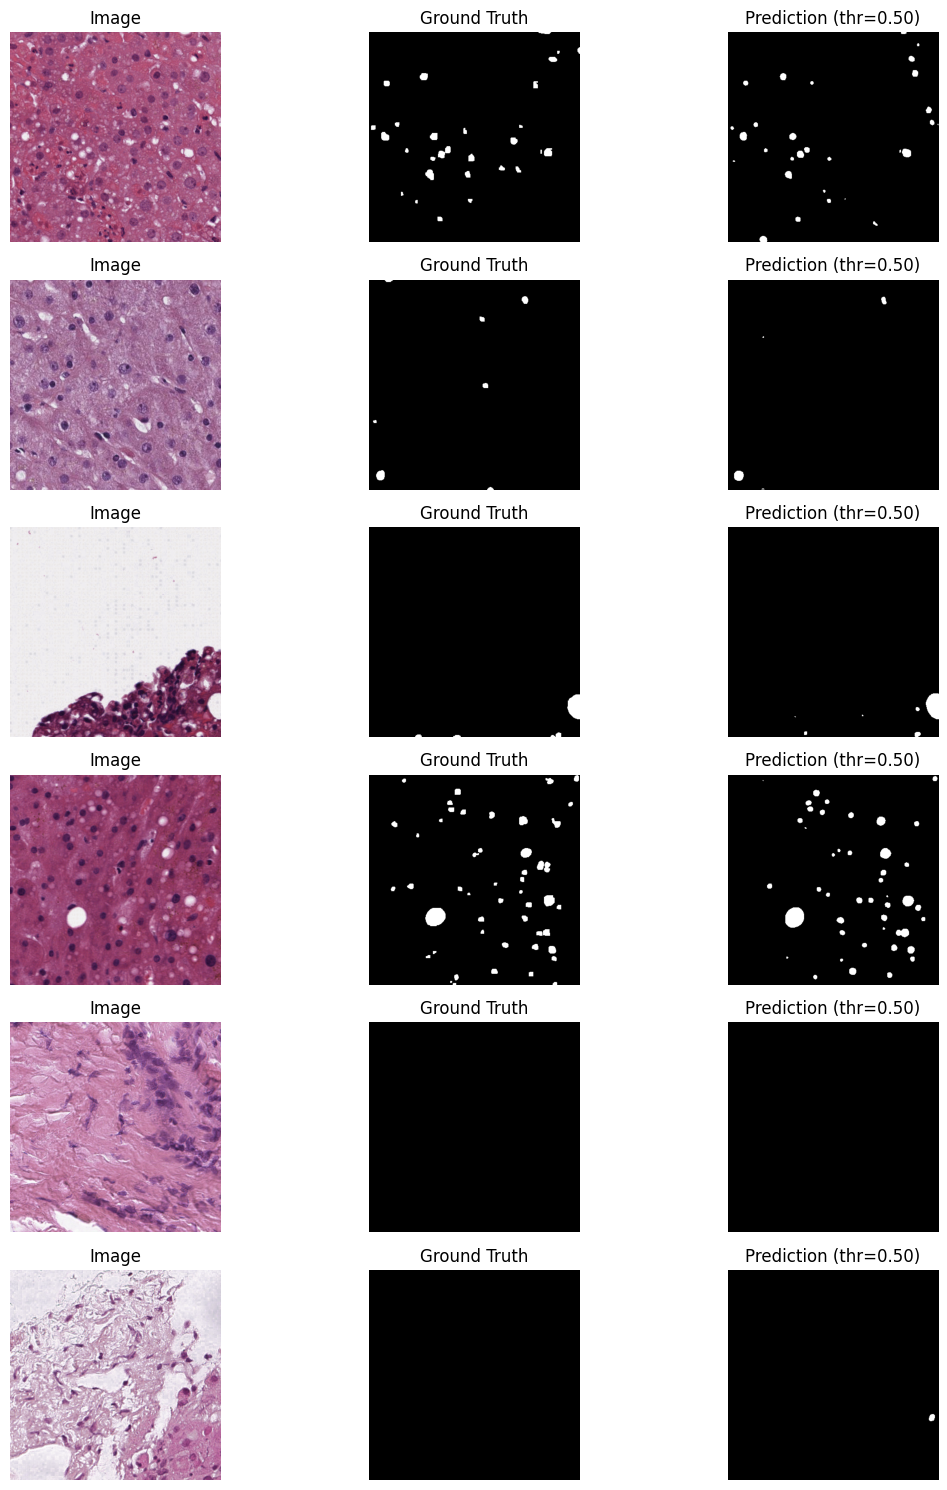

In [ ]:
# ============================================================
# SAVE TRAINING HISTORY (FULL OBJECT)
# Allows re-plotting without re-training
# ============================================================

HISTORY_PATH = os.path.join(CHECKPOINT_DIR, "history.npy") # Path to save the complete training history.
np.save(HISTORY_PATH, history, allow_pickle=True) # Save the history dictionary using NumPy.
print(f"[Saved] Training history object -> {HISTORY_PATH}")


# ============================================================
# TRAINING HISTORY VISUALIZATION (AUTO-SAVED FIGURES)
# ============================================================

def plot_history(history, save_dir, prefix="baseline"):
    """
    Generates and saves plots of training and validation metrics from the `history` dictionary.
    Plots include loss, Dice score, IoU, NaN counts, object count error, steatosis error, and learning rate.
    These plots are crucial for analyzing model convergence and performance over epochs.

    Args:
        history (dict): Dictionary containing epoch-wise training and validation metrics.
        save_dir (str): Directory where the generated plots will be saved.
        prefix (str): Prefix for the filenames of the saved plots.
    """

    os.makedirs(save_dir, exist_ok=True) # Ensure the save directory exists.
    epochs = np.arange(1, len(history["train_loss"]) + 1) # Generate epoch numbers for x-axis.

    def _save(fig, name):
        """Helper function to save a matplotlib figure."""
        fig.savefig(
            os.path.join(save_dir, f"{prefix}_{name}.png"),
            dpi=200,
            bbox_inches="tight"
        )

    # ---- Loss Plot ----
    fig = plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "loss") # Save the loss plot.
    plt.close(fig)

    # ---- Dice Score Plot ----
    fig = plt.figure()
    dm = np.array(history["dice_mean"])
    ds = np.array(history["dice_std"])
    plt.plot(epochs, dm, label="Validation Dice (mean)")
    plt.fill_between(epochs, dm - ds, dm + ds, alpha=0.2, label="± std")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Validation Dice vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "dice") # Save the Dice score plot.
    plt.close(fig)

    # ---- IoU Score Plot ----
    fig = plt.figure()
    im = np.array(history["iou_mean"])
    isd = np.array(history["iou_std"])
    plt.plot(epochs, im, label="Validation IoU (mean)")
    plt.fill_between(epochs, im - isd, im + isd, alpha=0.2, label="± std")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title("Validation IoU vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "iou") # Save the IoU plot.
    plt.close(fig)

    # ---- NaN Counts Plot ----
    fig = plt.figure()
    plt.plot(epochs, history["dice_nan"], label="Dice NaN")
    plt.plot(epochs, history["iou_nan"], label="IoU NaN")
    plt.xlabel("Epoch")
    plt.ylabel("Count")
    plt.title("NaN predictions vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "nan") # Save the NaN counts plot.
    plt.close(fig)

    # ---- Count Error Plot ----
    fig = plt.figure()
    ce = np.array(history["count_err_mean"])
    ces = np.array(history["count_err_std"])
    plt.plot(epochs, ce, label="Count Error (mean)")
    plt.fill_between(epochs, ce - ces, ce + ces, alpha=0.2, label="± std")
    plt.xlabel("Epoch")
    plt.ylabel("Count Error")
    plt.title("Validation Count Error vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "count_err") # Save the count error plot.
    plt.close(fig)

    # ---- Steatosis Error Plot ----
    fig = plt.figure()
    se = np.array(history["steat_err_mean"])
    ses = np.array(history["steat_err_std"])
    plt.plot(epochs, se, label="Steatosis Error (mean)")
    plt.fill_between(epochs, se - ses, se + ses, alpha=0.2, label="± std")
    plt.xlabel("Epoch")
    plt.ylabel("Error (%)")
    plt.title("Validation Steatosis Error vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "steat_err") # Save the steatosis error plot.
    plt.close(fig)

    # ---- Learning Rate Plot ----
    fig = plt.figure()
    plt.plot(epochs, history["lr"], label="Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.title("Learning Rate vs Epoch")
    plt.legend()
    plt.grid(True)
    _save(fig, "lr") # Save the learning rate plot.
    plt.close(fig)

    print(f"[Saved] All training figures -> {save_dir}")


# ============================================================
# QUALITATIVE VALIDATION EXAMPLES (AUTO-SAVED)
# ============================================================

def show_val_predictions(
    model,
    val_loader,
    device,
    thr=VAL_THRESH,
    n=6,
    seed=0,
    save_path=None
):
    """
    Displays and optionally saves qualitative validation examples, showing input image,
    ground truth mask, and model's predicted mask. Images are de-normalized for visualization.

    Args:
        model (torch.nn.Module): Trained model.
        val_loader (torch.utils.data.DataLoader): Validation data loader.
        device (torch.device): Compute device.
        thr (float): Threshold for binarizing predictions.
        n (int): Number of examples to display.
        seed (int): Random seed for reproducibility.
        save_path (str, optional): Path to save the plot. If None, the plot is only displayed.
    """

    rng = np.random.default_rng(seed) # Initialize random number generator for selecting examples.
    model.eval() # Set model to evaluation mode.

    all_batches = [] # Collect all validation batches.
    with torch.no_grad():
        for images, masks in val_loader:
            all_batches.append((images, masks))

    # Select a subset of batches to draw examples from.
    idxs = rng.choice(len(all_batches), size=min(len(all_batches), 10), replace=False)
    examples = [] # List to store (image, ground_truth, prediction) tuples.

    with torch.no_grad():
        for idx in idxs:
            images, masks = all_batches[idx]
            images = images.to(device)
            masks  = masks.to(device)

            probs = torch.sigmoid(model(images))[:, 0].cpu().numpy() # Get probability maps from model.
            gts   = (masks[:, 0].cpu().numpy() > 0.5)               # Binarize ground truth.

            for b in range(probs.shape[0]):
                img = images[b].cpu().numpy().transpose(1, 2, 0) # Convert image tensor to HWC format.
                img = img * 0.5 + 0.5  # De-normalize image for display (from [-1, 1] to [0, 1]).
                gt  = gts[b] # Ground truth mask.
                pr  = probs[b] >= thr # Binarized prediction.

                examples.append((img, gt, pr)) # Add example to list.
                if len(examples) >= n:
                    break
            if len(examples) >= n:
                break

    fig = plt.figure(figsize=(12, 2.5 * n)) # Create figure for displaying examples.
    for i, (img, gt, pr) in enumerate(examples):
        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(pr, cmap="gray")
        plt.title(f"Prediction (thr={thr:.2f})")
        plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight") # Save the plot if a path is provided.
        print(f"[Saved] Validation examples -> {save_path}")

    plt.show() # Display the plot.


# ============================================================
# USAGE (BASELINE)
# ============================================================

plot_history(
    history,
    save_dir=CHECKPOINT_DIR,
    prefix="baseline_noPP"
) # Generate and save all history plots.

show_val_predictions(
    model,
    val_loader,
    DEVICE,
    thr=VAL_THRESH,
    n=6,
    save_path=os.path.join(CHECKPOINT_DIR, "val_examples_baseline.png")
) # Generate and save qualitative validation prediction examples.